In [ ]:
!pip -q install transformers datasets evaluate accelerate scikit-learn pandas torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload: all_combined_cleaned.csv
CLEAN_PATH = list(uploaded.keys())[0]
print("Loaded:", CLEAN_PATH)

Saving all_combined_cleaned.csv to all_combined_cleaned.csv
Loaded: all_combined_cleaned.csv


In [ ]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    )

df = pd.read_csv(CLEAN_PATH)

# Columns in cleaned dataset
TEXT_COL = "content"
LABEL_COL = "label"
APP_COL = "app"

required_cols = {TEXT_COL, LABEL_COL, APP_COL, "score", "sentiment"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in {CLEAN_PATH}: {missing}. Found: {df.columns.tolist()}")

# Model
MODEL_NAME = "distilbert-base-uncased"
OUT_DIR = "/content/bert_sentiment_model"

# Label maps
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print("Rows:", len(df))
print(df[[APP_COL, "score", "sentiment", LABEL_COL, TEXT_COL]].head())

Rows: 142306
        app  score sentiment  label  \
0  Facebook      5  positive      2   
1  Facebook      1  negative      0   
2  Facebook      5  positive      2   
3  Facebook      5  positive      2   
4  Facebook      5  positive      2   

                                             content  
0                                          excellent  
1  Permanently disabled my account with no reason...  
2                                          Nice apps  
3                                               good  
4                                         verry good  


In [ ]:
from datasets import Dataset, ClassLabel, Features, Value

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["content"], truncation=True)

# ---- FIX: make sure content is valid text ----
df["content"] = df["content"].astype(str).fillna("").str.strip()
df = df[df["content"].str.len() > 0].copy()

# Ensure correct dtypes
df["reviewId"] = df["reviewId"].astype(str)
df["score"] = pd.to_numeric(df["score"], errors="coerce").fillna(0).astype(int)
df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)

# IMPORTANT: features must match ALL columns exactly
features = Features({
    "reviewId": Value("string"),
    "content": Value("string"),
    "score": Value("int64"),
    "app": Value("string"),
    "sentiment": Value("string"),
    "label": ClassLabel(num_classes=3, names=["negative", "neutral", "positive"]),
})

dataset = Dataset.from_pandas(df.reset_index(drop=True)).cast(features)

split = dataset.train_test_split(test_size=0.2, seed=42, stratify_by_column="label")

train_ds = split["train"].map(tokenize_fn, batched=True)
val_ds   = split["test"].map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Train size:", len(train_ds), "| Val size:", len(val_ds))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Casting the dataset:   0%|          | 0/142306 [00:00<?, ? examples/s]

Map:   0%|          | 0/113844 [00:00<?, ? examples/s]

Map:   0%|          | 0/28462 [00:00<?, ? examples/s]

Train size: 113844 | Val size: 28462


In [ ]:
# ---- Class weights (handles imbalance) ----
train_labels = np.array(train_ds["labels"])
class_counts = np.bincount(train_labels, minlength=3)
class_weights = class_counts.sum() / (3.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class counts:", class_counts)
print("Class weights:", class_weights.tolist())

# ---- Metrics ----
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
      logits, labels = eval_pred
      preds = np.argmax(logits, axis=1)
      return {
          "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
          "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
      }


# ---- Model ----
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

class WeightedTrainer(Trainer):
      def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
          labels = inputs["labels"]
          outputs = model(
              input_ids=inputs["input_ids"],
              attention_mask=inputs["attention_mask"]
          )
          logits = outputs.logits

          weights = class_weights.to(logits.device)
          loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
          loss = loss_fct(logits.view(-1, 3), labels.view(-1))

          return (loss, outputs) if return_outputs else loss

Class counts: [37117  6305 70422]
Class weights: [1.0223886966705322, 6.0187153816223145, 0.5388656854629517]


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.evaluate()

trainer.save_model(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)

print("✅ Saved model to:", OUT_DIR)

/tmp/ipython-input-2386324402.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.803100,0.701638,0.823203,0.649902
2,0.613900,0.776343,0.835254,0.658122
3,0.582800,0.861803,0.836343,0.653055


✅ Saved model to: /content/bert_sentiment_model


In [ ]:
OUT_DIR = "/content/bert_sentiment_model"
trainer.save_model(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)
print("Saved model to:", OUT_DIR)

Saved model to: /content/bert_sentiment_model


In [ ]:
from datasets import Dataset
import numpy as np

# Make a dataset from your full cleaned df (df should still exist)
full_ds = Dataset.from_pandas(df.reset_index(drop=True)).map(tokenize_fn, batched=True)

preds = trainer.predict(full_ds)
pred_ids = np.argmax(preds.predictions, axis=1)

df["predicted_sentiment"] = [ID2LABEL[i] for i in pred_ids]

PRED_PATH = "/content/all_reviews_with_predictions.csv"
df.to_csv(PRED_PATH, index=False)

print("✅ Saved:", PRED_PATH)
df.head()

Map:   0%|          | 0/142306 [00:00<?, ? examples/s]

✅ Saved: /content/all_reviews_with_predictions.csv


,reviewId,content,score,app,sentiment,label,predicted_sentiment
0,b83f57a1-5a02-4a32-8e2c-05736cec1669,excellent,5,Facebook,positive,2,positive
1,eeeadb3a-4aca-4d44-a20c-9ba106f31c1e,Permanently disabled my account with no reason...,1,Facebook,negative,0,negative
2,3994417b-f1c9-4069-bf7f-d88679cf04d0,Nice apps,5,Facebook,positive,2,positive
3,f0cba101-024d-4275-a6a5-14bb9bc3199d,good,5,Facebook,positive,2,positive
4,59bec77d-ec51-464b-92fb-4cecc88c8e88,verry good,5,Facebook,positive,2,positive


In [ ]:
import matplotlib.pyplot as plt
import os

CHART_DIR = "/content/charts"
os.makedirs(CHART_DIR, exist_ok=True)

def charts_for_app(app_query):
    subset = df[df["app"].astype(str).str.contains(app_query, case=False, na=False)].copy()
    if len(subset) == 0:
        print("❌ No reviews found for:", app_query)
        return

    counts = subset["predicted_sentiment"].value_counts().reindex(
        ["negative", "neutral", "positive"]
    ).fillna(0)

    # Bar
    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"Sentiment Distribution: {app_query}")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.tight_layout()
    bar_path = f"{CHART_DIR}/{app_query}_bar.png".replace(" ", "_")
    plt.savefig(bar_path, dpi=200)
    plt.show()

    # Pie
    plt.figure()
    counts.plot(kind="pie", autopct="%1.1f%%")
    plt.title(f"Sentiment Percentage: {app_query}")
    plt.ylabel("")
    plt.tight_layout()
    pie_path = f"{CHART_DIR}/{app_query}_pie.png".replace(" ", "_")
    plt.savefig(pie_path, dpi=200)
    plt.show()

    print("✅ Saved:", bar_path)
    print("✅ Saved:", pie_path)

# Example:
# charts_for_app("Instagram")

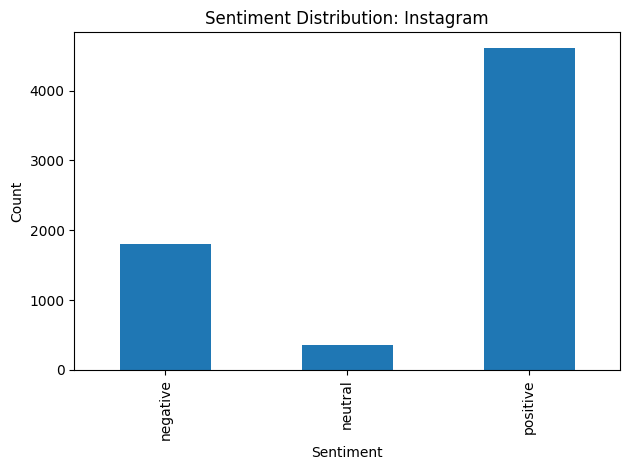

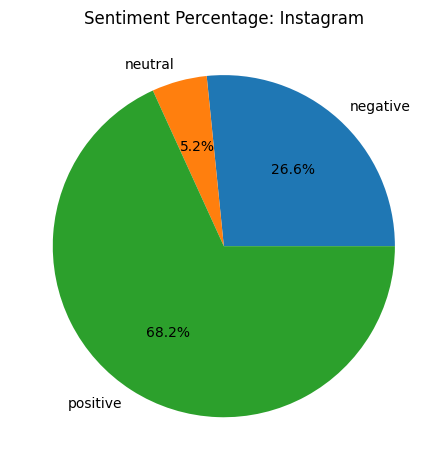

✅ Saved: /content/charts/Instagram_bar.png
✅ Saved: /content/charts/Instagram_pie.png


In [ ]:
charts_for_app("Instagram")

In [ ]:
from google.colab import files
import shutil

files.download("/content/all_reviews_with_predictions.csv")

shutil.make_archive("/content/bert_sentiment_model", "zip", "/content/bert_sentiment_model")
files.download("/content/bert_sentiment_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>